In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
# Khai báo đường dẫn module
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.phase_space_reconstruction import delay_embedding, ksg_mi_1, ksg_mi_2, false_nearest_neighbors, cao_method
from core_ntsa.noise_tools import add_white_noise 


In [2]:
lorenz_data = simulate_lorenz(t_span=60, dt=0.01)
x_clean = lorenz_data[0]
print(len(x_clean))
y_clean = lorenz_data[1]  # Lấy thêm trục Y gốc
z_clean = lorenz_data[2]  # Lấy thêm trục Z gốc


x_noise = add_white_noise(x_clean, snr_db=30.0)

5000


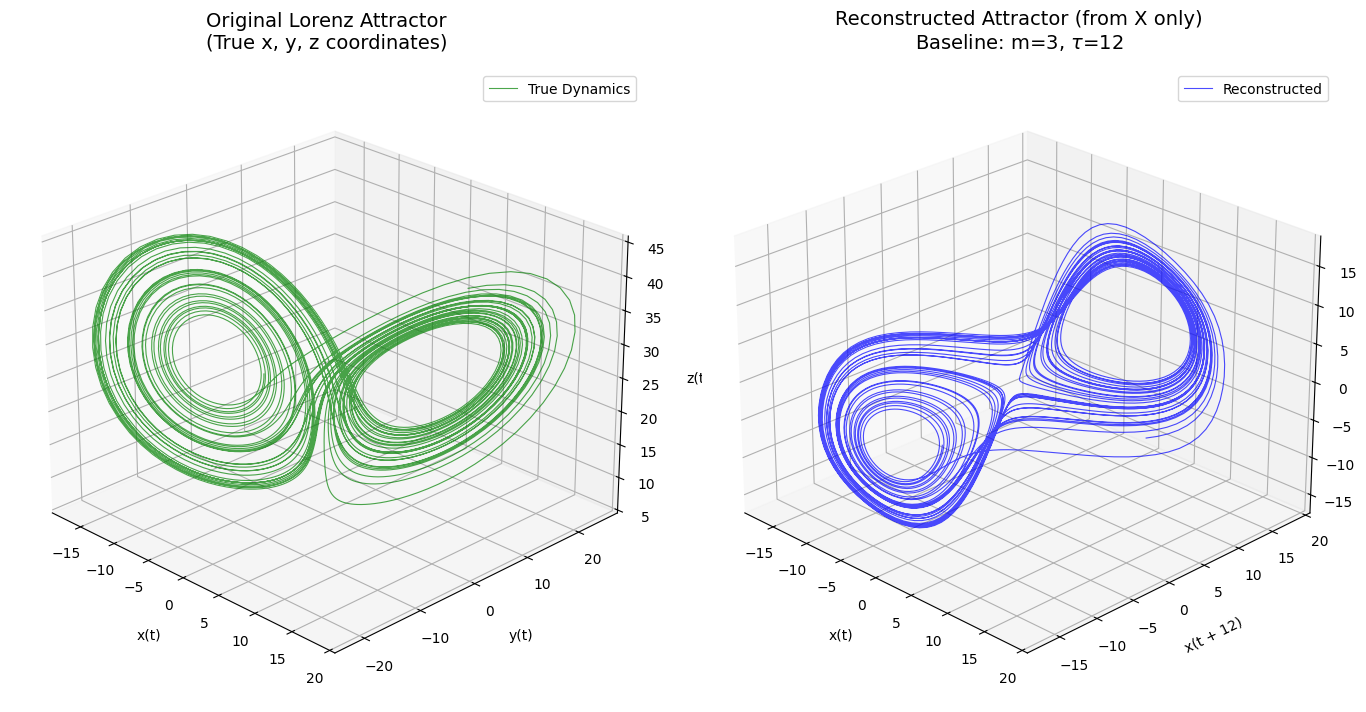

In [3]:
tau_baseline = 12
m_baseline = 3

# Nhúng không gian pha chỉ từ trục X
phase_space_recon = delay_embedding(x_clean, tau_baseline, m_baseline)

# Lấy số lượng vector L để vẽ đồ thị gốc sao cho độ dài đồng bộ với đồ thị tái tạo
L_recon = phase_space_recon.shape[0]

# ==========================================
# 3. TRỰC QUAN HÓA SO SÁNH (GRID 1x2)
# ==========================================
fig = plt.figure(figsize=(14, 7))

# Đồ thị 1: Không gian pha chuẩn (Original Lorenz Attractor)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(x_clean[:L_recon], 
         y_clean[:L_recon], 
         z_clean[:L_recon], 
         color='green', alpha=0.7, linewidth=0.8, label='True Dynamics')

ax1.set_title("Original Lorenz Attractor\n(True x, y, z coordinates)", fontsize=14, pad=15)
ax1.set_xlabel("x(t)", labelpad=10)
ax1.set_ylabel("y(t)", labelpad=10)
ax1.set_zlabel("z(t)", labelpad=10)
ax1.view_init(elev=25, azim=-45) # Giữ cùng một góc nhìn camera
ax1.legend()

# Đồ thị 2: Không gian pha tái tạo (Reconstructed from X)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(phase_space_recon[:, 0], 
         phase_space_recon[:, 1], 
         phase_space_recon[:, 2], 
         color='blue', alpha=0.7, linewidth=0.8, label='Reconstructed')

ax2.set_title(f"Reconstructed Attractor (from X only)\nBaseline: m={m_baseline}, $\\tau$={tau_baseline}", fontsize=14, pad=15)
ax2.set_xlabel("x(t)", labelpad=10)
ax2.set_ylabel(f"x(t + {tau_baseline})", labelpad=10)
ax2.set_zlabel(f"x(t + {2*tau_baseline})", labelpad=10)
ax2.view_init(elev=25, azim=-45) # Giữ cùng một góc nhìn camera
ax2.legend()

plt.tight_layout()
plt.show()

Time lag toi uu (KSG1): 16
Time lag toi uu (KSG2): 16


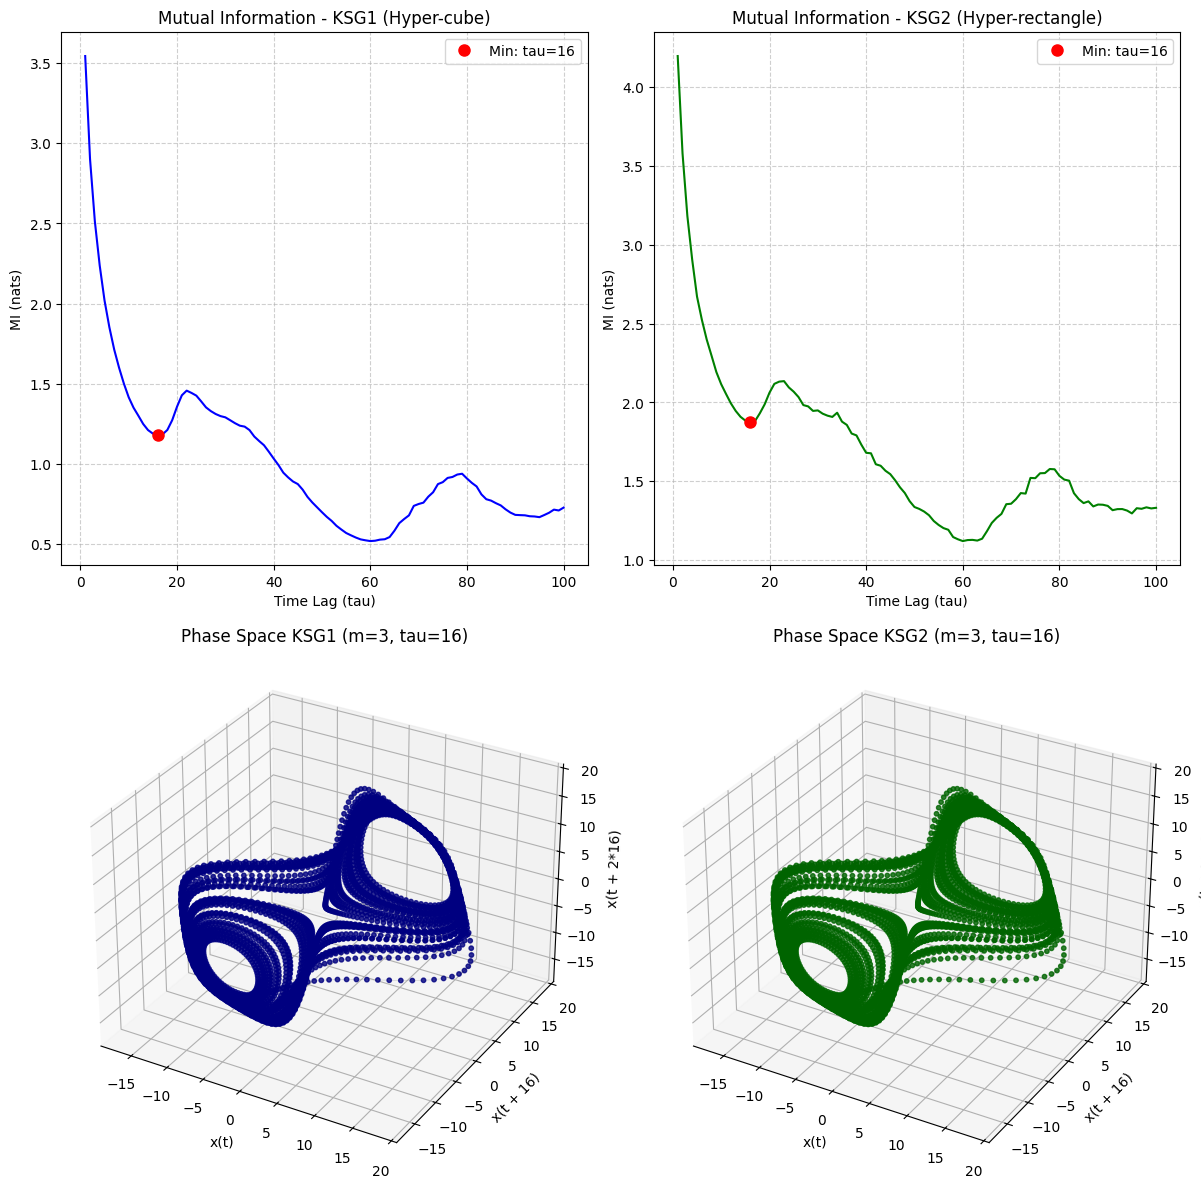

In [4]:
def find_first_local_minimum(mi_values, tau_range):
    """
    Tim diem cuc tieu cuc bo dau tien cua mang Mutual Information.
    """
    for i in range(1, len(mi_values) - 1):
        if mi_values[i - 1] > mi_values[i] and mi_values[i] < mi_values[i + 1]:
            return tau_range[i]
    return tau_range[np.argmin(mi_values)]

# 1. Thiet lap tham so
max_tau = 100
tau_range = np.arange(1, max_tau + 1)
m_baseline = 3

mi1_list = []
mi2_list = []

# 2. Tinh toan Mutual Information bang ky thuat tu tre (Auto-delay)
for tau in tau_range:
    # Dich vong tin hieu de tao x(t) va x(t + tau)
    x_t = x_clean[:-tau]
    x_t_plus_tau = x_clean[tau:]
    
    mi1 = ksg_mi_1(x_t, x_t_plus_tau)
    mi2 = ksg_mi_2(x_t, x_t_plus_tau)
    
    mi1_list.append(mi1)
    mi2_list.append(mi2)

mi1_array = np.array(mi1_list)
mi2_array = np.array(mi2_list)

# 3. Tim Time Lag (tau) toi uu
tau_opt_1 = find_first_local_minimum(mi1_array, tau_range)
tau_opt_2 = find_first_local_minimum(mi2_array, tau_range)

print(f"Time lag toi uu (KSG1): {tau_opt_1}")
print(f"Time lag toi uu (KSG2): {tau_opt_2}")

# 4. Tai tao Khong gian pha
ps_ksg1 = delay_embedding(x_clean, tau_opt_1, m_baseline)
ps_ksg2 = delay_embedding(x_clean, tau_opt_2, m_baseline)

# 5. Truc quan hoa (Grid 2x2)
fig = plt.figure(figsize=(12, 12))

# ==================== DONG 1: MUTUAL INFORMATION ====================
# Do thi 1: MI cua KSG1
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(tau_range, mi1_array, color='blue', linewidth=1.5)
ax1.plot(tau_opt_1, mi1_array[tau_opt_1 - 1], 'ro', markersize=8, 
         label=f'Min: tau={tau_opt_1}')
ax1.set_title("Mutual Information - KSG1 (Hyper-cube)")
ax1.set_xlabel("Time Lag (tau)")
ax1.set_ylabel("MI (nats)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Do thi 2: MI cua KSG2
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(tau_range, mi2_array, color='green', linewidth=1.5)
ax2.plot(tau_opt_2, mi2_array[tau_opt_2 - 1], 'ro', markersize=8, 
         label=f'Min: tau={tau_opt_2}')
ax2.set_title("Mutual Information - KSG2 (Hyper-rectangle)")
ax2.set_xlabel("Time Lag (tau)")
ax2.set_ylabel("MI (nats)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# ==================== DONG 2: KHONG GIAN PHA 3D ====================
# Do thi 3: Phase Space KSG1
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot(ps_ksg1[:, 0], ps_ksg1[:, 1], ps_ksg1[:, 2], 
         color='gray', alpha=0.3, linewidth=0.5)
ax3.scatter(ps_ksg1[:, 0], ps_ksg1[:, 1], ps_ksg1[:, 2], 
            color='navy', s=10, alpha=0.8)
ax3.set_title(f"Phase Space KSG1 (m={m_baseline}, tau={tau_opt_1})")
ax3.set_xlabel("x(t)")
ax3.set_ylabel(f"x(t + {tau_opt_1})")
ax3.set_zlabel(f"x(t + 2*{tau_opt_1})")

# Do thi 4: Phase Space KSG2
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot(ps_ksg2[:, 0], ps_ksg2[:, 1], ps_ksg2[:, 2], 
         color='gray', alpha=0.3, linewidth=0.5)
ax4.scatter(ps_ksg2[:, 0], ps_ksg2[:, 1], ps_ksg2[:, 2], 
            color='darkgreen', s=10, alpha=0.8)
ax4.set_title(f"Phase Space KSG2 (m={m_baseline}, tau={tau_opt_2})")
ax4.set_xlabel("x(t)")
ax4.set_ylabel(f"x(t + {tau_opt_2})")
ax4.set_zlabel(f"x(t + 2*{tau_opt_2})")

plt.tight_layout()
plt.show()

So chieu toi uu theo FNN: 3
So chieu toi uu theo Cao's Method: 4


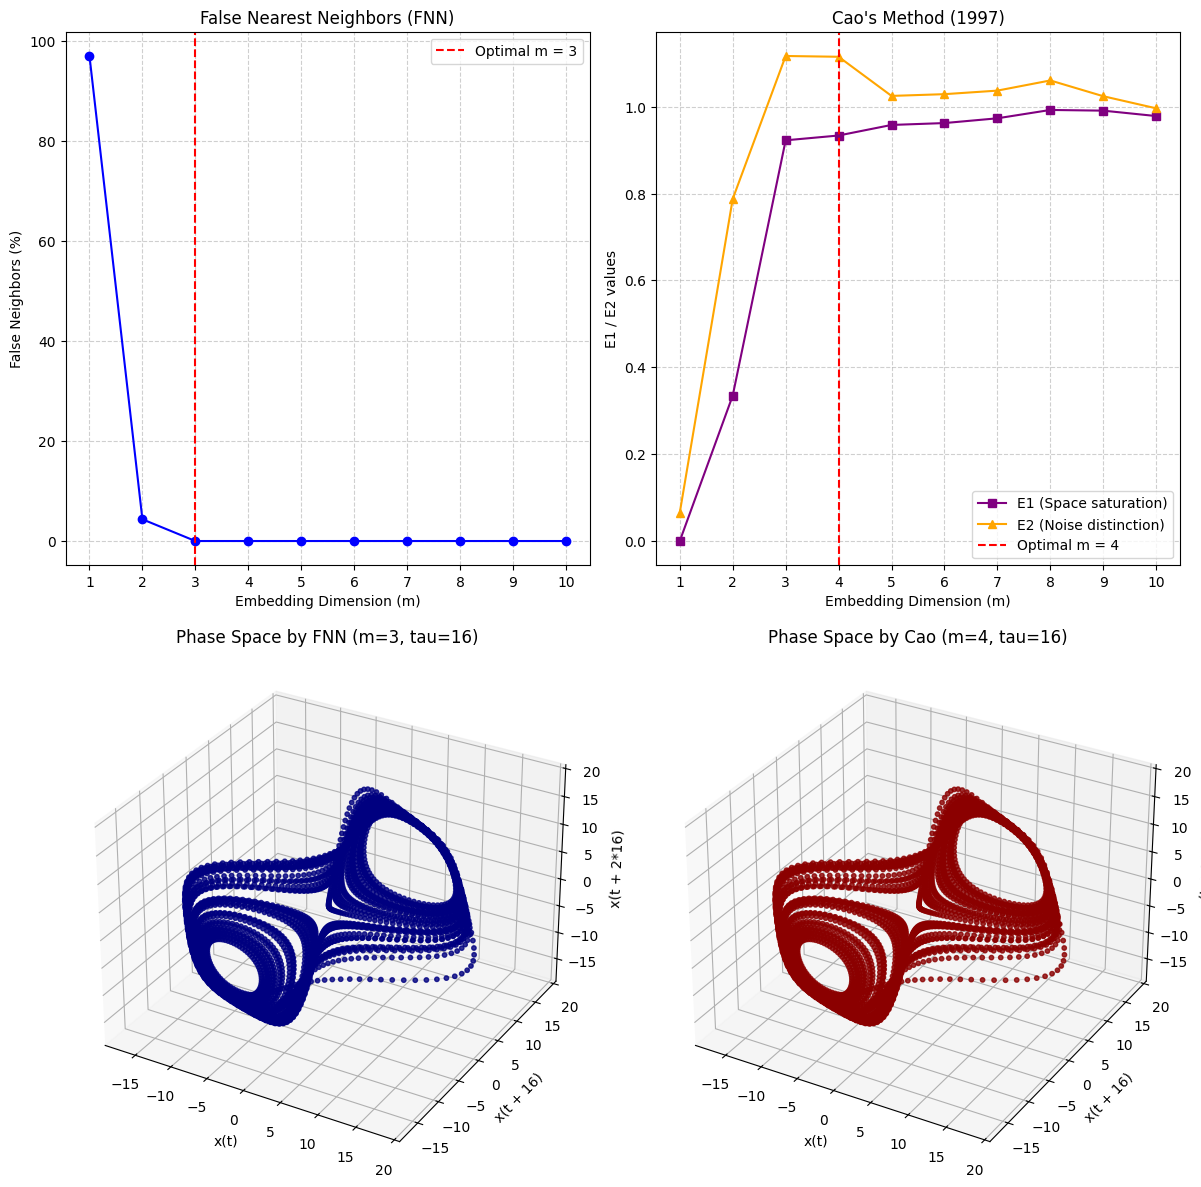

In [5]:
def find_optimal_m_fnn(dims, fnn_percentages, threshold=1.0):
    """
    Tìm số chiều m tối ưu từ thuật toán FNN.
    Lựa chọn m đầu tiên mà tại đó tỷ lệ láng giềng giả nhỏ hơn ngưỡng threshold (%).
    """
    valid_indices = np.where(np.array(fnn_percentages) < threshold)[0]
    if len(valid_indices) > 0:
        return dims[valid_indices[0]]
    # Nếu không hội tụ, trả về m tại điểm có tỷ lệ nhỏ nhất
    return dims[np.argmin(fnn_percentages)]

def find_optimal_m_cao(dims, E1, threshold_diff=0.03):
    """
    Tìm số chiều m tối ưu từ thuật toán Cao (1997).
    Lựa chọn m khi đại lượng E1 bắt đầu bão hòa (sự thay đổi giữa các bậc rất nhỏ).
    """
    E1_array = np.array(E1)
    for i in range(1, len(E1_array)):
        if abs(E1_array[i] - E1_array[i-1]) < threshold_diff:
            # Trả về số chiều tương ứng với điểm bão hòa
            return dims[i]
    return dims[-1]

# 1. Thiết lập tham số đầu vào
# Kế thừa độ trễ tối ưu (tau = 9) đã tìm được từ bước Mutual Information
opt_tau = 16
max_m_check = 10

# 2. Chạy thuật toán FNN và Cao's Method
dims_fnn, fnn_percentages = false_nearest_neighbors(x_clean, opt_tau, max_m=max_m_check)
dims_cao, E1_vals, E2_vals = cao_method(x_clean, opt_tau, max_m=max_m_check)

# 3. Tự động xác định số chiều nhúng tối ưu
m_opt_fnn = find_optimal_m_fnn(dims_fnn, fnn_percentages)
m_opt_cao = find_optimal_m_cao(dims_cao, E1_vals)

print(f"So chieu toi uu theo FNN: {m_opt_fnn}")
print(f"So chieu toi uu theo Cao's Method: {m_opt_cao}")

# 4. Tái tạo Không gian pha bằng số chiều đã tìm được
ps_fnn = delay_embedding(x_clean, opt_tau, m_opt_fnn)
ps_cao = delay_embedding(x_clean, opt_tau, m_opt_cao)

# ==========================================
# 5. TRỰC QUAN HÓA SO SÁNH (GRID 2x2)
# ==========================================
fig = plt.figure(figsize=(12, 12))

# Đồ thị 1: False Nearest Neighbors (FNN)
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(dims_fnn, fnn_percentages, marker='o', color='blue', linewidth=1.5)
ax1.axvline(x=m_opt_fnn, color='red', linestyle='--', label=f'Optimal m = {m_opt_fnn}')
ax1.set_title("False Nearest Neighbors (FNN)")
ax1.set_xlabel("Embedding Dimension (m)")
ax1.set_ylabel("False Neighbors (%)")
ax1.set_xticks(dims_fnn)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 2: Cao's Method (E1 và E2)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(dims_cao[:len(E1_vals)], E1_vals, marker='s', color='purple', label='E1 (Space saturation)')
# Kiểm tra độ dài E2 để tránh lỗi index (do thuật toán Cao tính E2 phụ thuộc chiều d)
if len(E2_vals) > 0:
    ax2.plot(dims_cao[:len(E2_vals)], E2_vals, marker='^', color='orange', label='E2 (Noise distinction)')
ax2.axvline(x=m_opt_cao, color='red', linestyle='--', label=f'Optimal m = {m_opt_cao}')
ax2.set_title("Cao's Method (1997)")
ax2.set_xlabel("Embedding Dimension (m)")
ax2.set_ylabel("E1 / E2 values")
ax2.set_xticks(dims_cao)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 3: Không gian pha theo m của FNN
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# Dù m_opt có lớn hơn 3, ta vẫn chỉ vẽ 3 chiều đầu tiên để trực quan hóa
ax3.plot(ps_fnn[:, 0], ps_fnn[:, 1], ps_fnn[:, 2], color='gray', alpha=0.3, linewidth=0.5)
ax3.scatter(ps_fnn[:, 0], ps_fnn[:, 1], ps_fnn[:, 2], color='navy', s=10, alpha=0.8)
ax3.set_title(f"Phase Space by FNN (m={m_opt_fnn}, tau={opt_tau})")
ax3.set_xlabel("x(t)")
ax3.set_ylabel(f"x(t + {opt_tau})")
ax3.set_zlabel(f"x(t + 2*{opt_tau})")

# Đồ thị 4: Không gian pha theo m của Cao's Method
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot(ps_cao[:, 0], ps_cao[:, 1], ps_cao[:, 2], color='gray', alpha=0.3, linewidth=0.5)
ax4.scatter(ps_cao[:, 0], ps_cao[:, 1], ps_cao[:, 2], color='darkred', s=10, alpha=0.8)
ax4.set_title(f"Phase Space by Cao (m={m_opt_cao}, tau={opt_tau})")
ax4.set_xlabel("x(t)")
ax4.set_ylabel(f"x(t + {opt_tau})")
ax4.set_zlabel(f"x(t + 2*{opt_tau})")

plt.tight_layout()
plt.show()

# DATA NOISE

So chieu toi uu theo FNN: 3
So chieu toi uu theo Cao's Method: 6


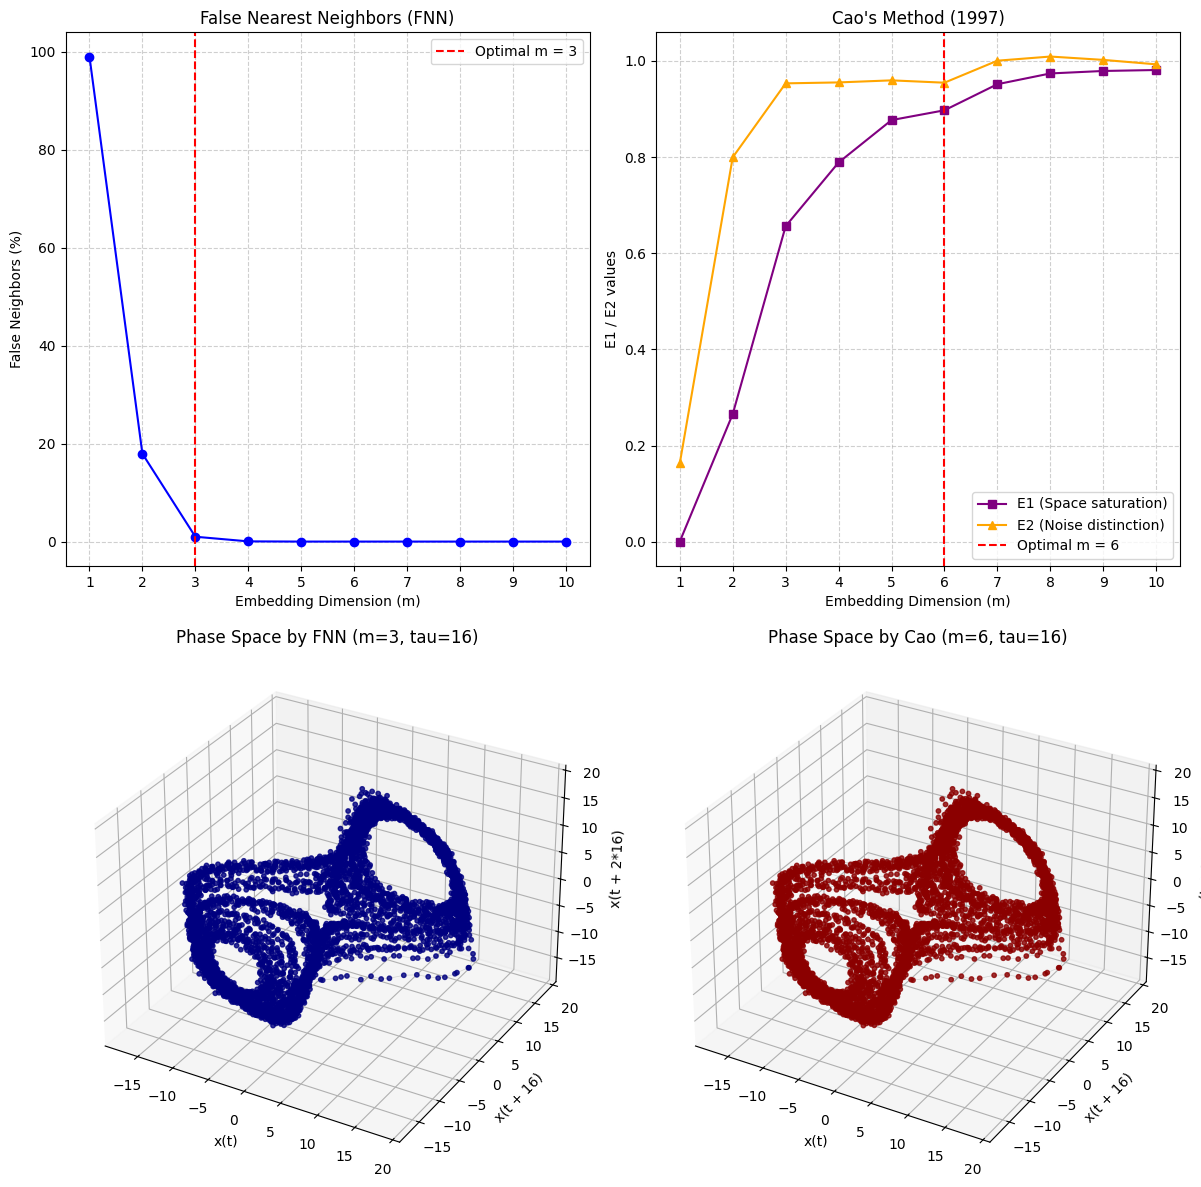

In [6]:
def find_optimal_m_fnn(dims, fnn_percentages, threshold=1.0):
    """
    Tìm số chiều m tối ưu từ thuật toán FNN.
    Lựa chọn m đầu tiên mà tại đó tỷ lệ láng giềng giả nhỏ hơn ngưỡng threshold (%).
    """
    valid_indices = np.where(np.array(fnn_percentages) < threshold)[0]
    if len(valid_indices) > 0:
        return dims[valid_indices[0]]
    # Nếu không hội tụ, trả về m tại điểm có tỷ lệ nhỏ nhất
    return dims[np.argmin(fnn_percentages)]

def find_optimal_m_cao(dims, E1, threshold_diff=0.03):
    """
    Tìm số chiều m tối ưu từ thuật toán Cao (1997).
    Lựa chọn m khi đại lượng E1 bắt đầu bão hòa (sự thay đổi giữa các bậc rất nhỏ).
    """
    E1_array = np.array(E1)
    for i in range(1, len(E1_array)):
        if abs(E1_array[i] - E1_array[i-1]) < threshold_diff:
            # Trả về số chiều tương ứng với điểm bão hòa
            return dims[i]
    return dims[-1]

# 1. Thiết lập tham số đầu vào
# Kế thừa độ trễ tối ưu (tau = 9) đã tìm được từ bước Mutual Information
opt_tau = 16
max_m_check = 10

# 2. Chạy thuật toán FNN và Cao's Method
dims_fnn, fnn_percentages = false_nearest_neighbors(x_noise, opt_tau, max_m=max_m_check)
dims_cao, E1_vals, E2_vals = cao_method(x_noise, opt_tau, max_m=max_m_check)

# 3. Tự động xác định số chiều nhúng tối ưu
m_opt_fnn = find_optimal_m_fnn(dims_fnn, fnn_percentages)
m_opt_cao = find_optimal_m_cao(dims_cao, E1_vals)

print(f"So chieu toi uu theo FNN: {m_opt_fnn}")
print(f"So chieu toi uu theo Cao's Method: {m_opt_cao}")

# 4. Tái tạo Không gian pha bằng số chiều đã tìm được
ps_fnn = delay_embedding(x_noise, opt_tau, m_opt_fnn)
ps_cao = delay_embedding(x_noise, opt_tau, m_opt_cao)

# ==========================================
# 5. TRỰC QUAN HÓA SO SÁNH (GRID 2x2)
# ==========================================
fig = plt.figure(figsize=(12, 12))

# Đồ thị 1: False Nearest Neighbors (FNN)
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(dims_fnn, fnn_percentages, marker='o', color='blue', linewidth=1.5)
ax1.axvline(x=m_opt_fnn, color='red', linestyle='--', label=f'Optimal m = {m_opt_fnn}')
ax1.set_title("False Nearest Neighbors (FNN)")
ax1.set_xlabel("Embedding Dimension (m)")
ax1.set_ylabel("False Neighbors (%)")
ax1.set_xticks(dims_fnn)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 2: Cao's Method (E1 và E2)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(dims_cao[:len(E1_vals)], E1_vals, marker='s', color='purple', label='E1 (Space saturation)')
# Kiểm tra độ dài E2 để tránh lỗi index (do thuật toán Cao tính E2 phụ thuộc chiều d)
if len(E2_vals) > 0:
    ax2.plot(dims_cao[:len(E2_vals)], E2_vals, marker='^', color='orange', label='E2 (Noise distinction)')
ax2.axvline(x=m_opt_cao, color='red', linestyle='--', label=f'Optimal m = {m_opt_cao}')
ax2.set_title("Cao's Method (1997)")
ax2.set_xlabel("Embedding Dimension (m)")
ax2.set_ylabel("E1 / E2 values")
ax2.set_xticks(dims_cao)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 3: Không gian pha theo m của FNN
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# Dù m_opt có lớn hơn 3, ta vẫn chỉ vẽ 3 chiều đầu tiên để trực quan hóa
ax3.plot(ps_fnn[:, 0], ps_fnn[:, 1], ps_fnn[:, 2], color='gray', alpha=0.3, linewidth=0.5)
ax3.scatter(ps_fnn[:, 0], ps_fnn[:, 1], ps_fnn[:, 2], color='navy', s=10, alpha=0.8)
ax3.set_title(f"Phase Space by FNN (m={m_opt_fnn}, tau={opt_tau})")
ax3.set_xlabel("x(t)")
ax3.set_ylabel(f"x(t + {opt_tau})")
ax3.set_zlabel(f"x(t + 2*{opt_tau})")

# Đồ thị 4: Không gian pha theo m của Cao's Method
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot(ps_cao[:, 0], ps_cao[:, 1], ps_cao[:, 2], color='gray', alpha=0.3, linewidth=0.5)
ax4.scatter(ps_cao[:, 0], ps_cao[:, 1], ps_cao[:, 2], color='darkred', s=10, alpha=0.8)
ax4.set_title(f"Phase Space by Cao (m={m_opt_cao}, tau={opt_tau})")
ax4.set_xlabel("x(t)")
ax4.set_ylabel(f"x(t + {opt_tau})")
ax4.set_zlabel(f"x(t + 2*{opt_tau})")

plt.tight_layout()
plt.show()

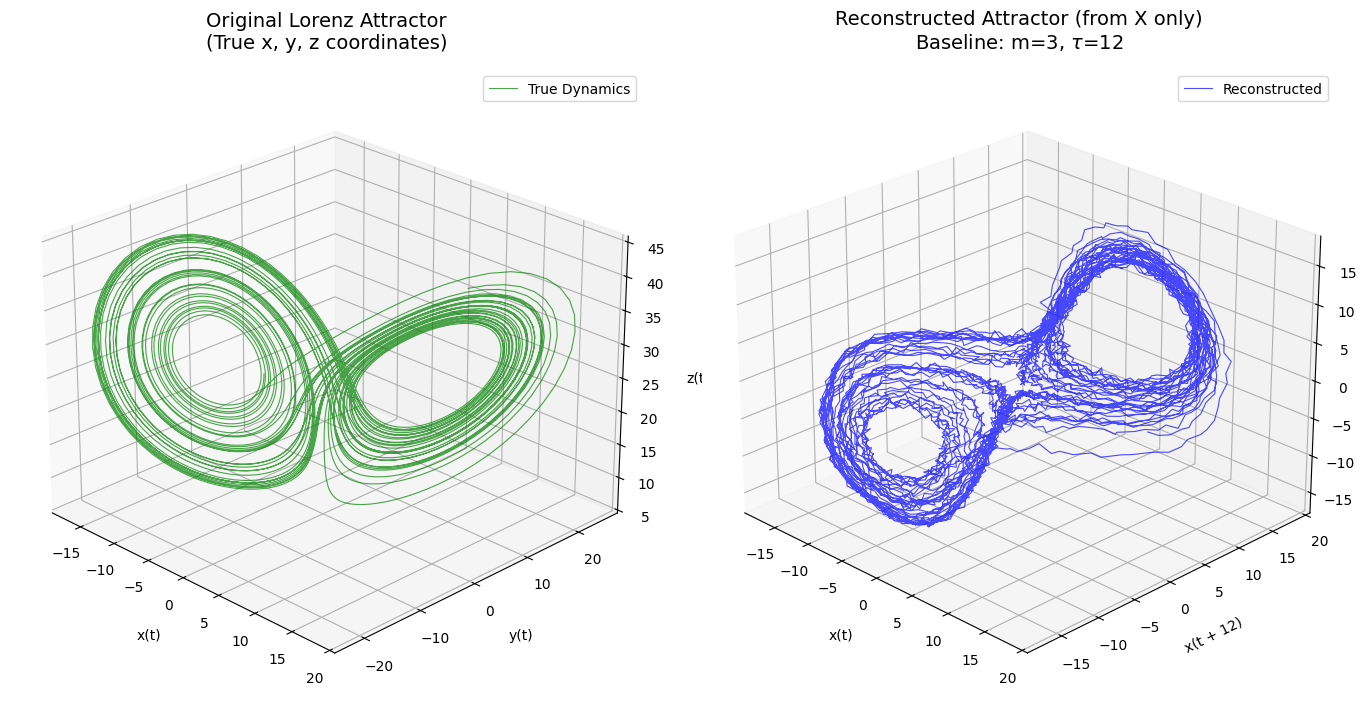

In [26]:
tau_baseline = 12
m_baseline = 3

# Nhúng không gian pha chỉ từ trục X
phase_space_recon = delay_embedding(x_noise, tau_baseline, m_baseline)

# Lấy số lượng vector L để vẽ đồ thị gốc sao cho độ dài đồng bộ với đồ thị tái tạo
L_recon = phase_space_recon.shape[0]

# ==========================================
# 3. TRỰC QUAN HÓA SO SÁNH (GRID 1x2)
# ==========================================
fig = plt.figure(figsize=(14, 7))

# Đồ thị 1: Không gian pha chuẩn (Original Lorenz Attractor)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(x_clean[:L_recon], 
         y_clean[:L_recon], 
         z_clean[:L_recon], 
         color='green', alpha=0.7, linewidth=0.8, label='True Dynamics')

ax1.set_title("Original Lorenz Attractor\n(True x, y, z coordinates)", fontsize=14, pad=15)
ax1.set_xlabel("x(t)", labelpad=10)
ax1.set_ylabel("y(t)", labelpad=10)
ax1.set_zlabel("z(t)", labelpad=10)
ax1.view_init(elev=25, azim=-45) # Giữ cùng một góc nhìn camera
ax1.legend()

# Đồ thị 2: Không gian pha tái tạo (Reconstructed from X)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(phase_space_recon[:, 0], 
         phase_space_recon[:, 1], 
         phase_space_recon[:, 2], 
         color='blue', alpha=0.7, linewidth=0.8, label='Reconstructed')

ax2.set_title(f"Reconstructed Attractor (from X only)\nBaseline: m={m_baseline}, $\\tau$={tau_baseline}", fontsize=14, pad=15)
ax2.set_xlabel("x(t)", labelpad=10)
ax2.set_ylabel(f"x(t + {tau_baseline})", labelpad=10)
ax2.set_zlabel(f"x(t + {2*tau_baseline})", labelpad=10)
ax2.view_init(elev=25, azim=-45) # Giữ cùng một góc nhìn camera
ax2.legend()

plt.tight_layout()
plt.show()

Time lag toi uu (KSG1): 14
Time lag toi uu (KSG2): 14


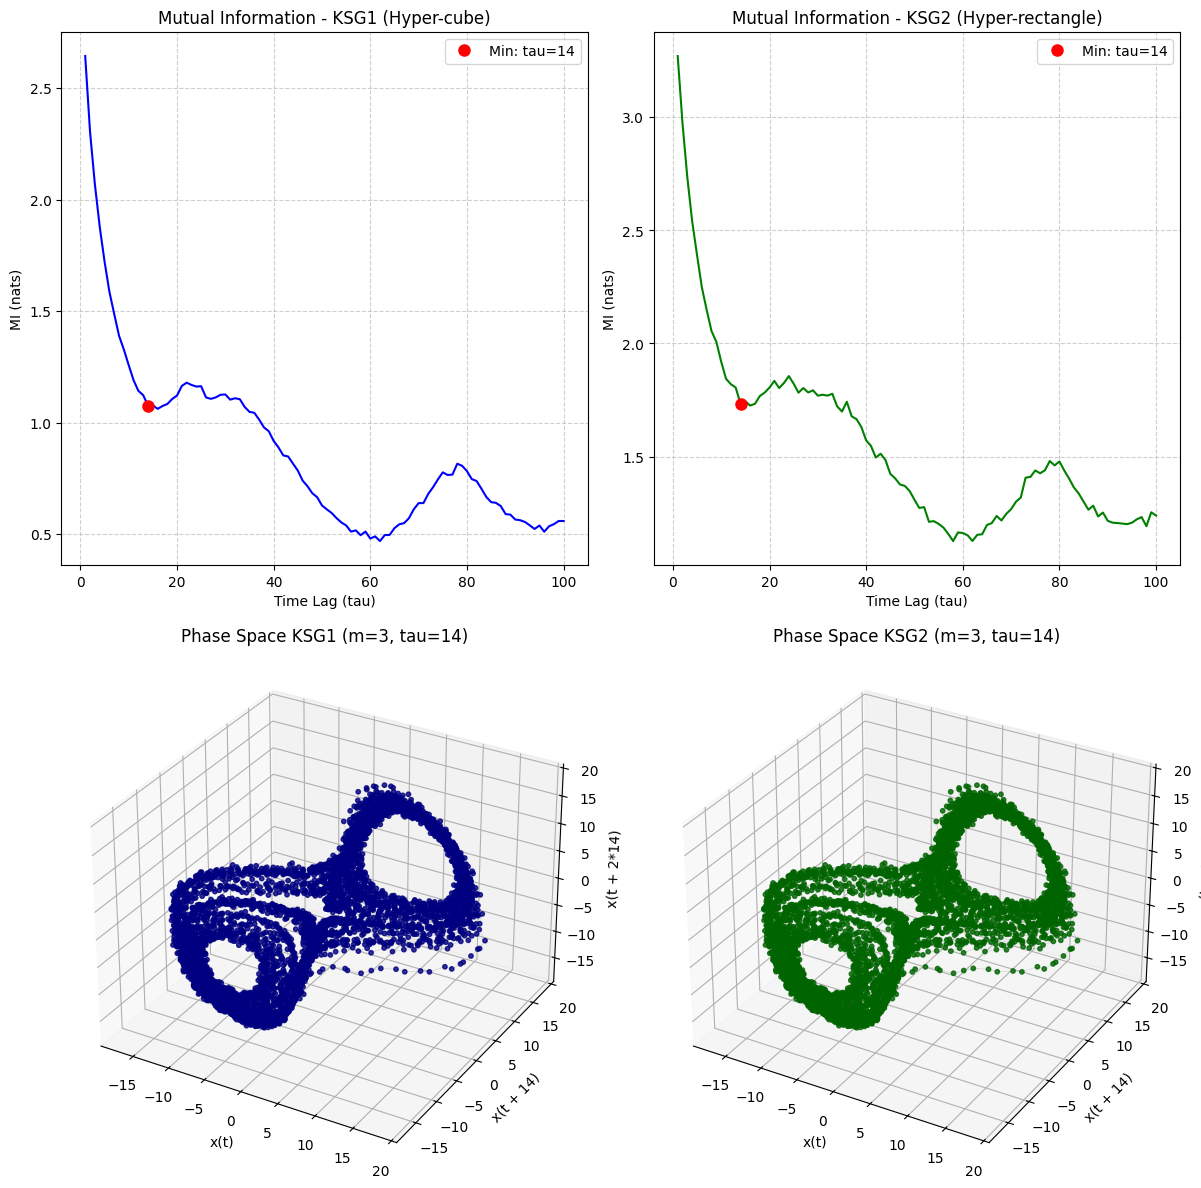

In [27]:
def find_first_local_minimum(mi_values, tau_range):
    """
    Tim diem cuc tieu cuc bo dau tien cua mang Mutual Information.
    """
    for i in range(1, len(mi_values) - 1):
        if mi_values[i - 1] > mi_values[i] and mi_values[i] < mi_values[i + 1]:
            return tau_range[i]
    return tau_range[np.argmin(mi_values)]

# 1. Thiet lap tham so
max_tau = 100
tau_range = np.arange(1, max_tau + 1)
m_baseline = 3

mi1_list = []
mi2_list = []

# 2. Tinh toan Mutual Information bang ky thuat tu tre (Auto-delay)
for tau in tau_range:
    # Dich vong tin hieu de tao x(t) va x(t + tau)
    x_t = x_noise[:-tau]
    x_t_plus_tau = x_noise[tau:]
    
    mi1 = ksg_mi_1(x_t, x_t_plus_tau)
    mi2 = ksg_mi_2(x_t, x_t_plus_tau)
    
    mi1_list.append(mi1)
    mi2_list.append(mi2)

mi1_array = np.array(mi1_list)
mi2_array = np.array(mi2_list)

# 3. Tim Time Lag (tau) toi uu
tau_opt_1 = find_first_local_minimum(mi1_array, tau_range)
tau_opt_2 = find_first_local_minimum(mi2_array, tau_range)

print(f"Time lag toi uu (KSG1): {tau_opt_1}")
print(f"Time lag toi uu (KSG2): {tau_opt_2}")

# 4. Tai tao Khong gian pha
ps_ksg1 = delay_embedding(x_noise, tau_opt_1, m_baseline)
ps_ksg2 = delay_embedding(x_noise, tau_opt_2, m_baseline)

# 5. Truc quan hoa (Grid 2x2)
fig = plt.figure(figsize=(12, 12))

# ==================== DONG 1: MUTUAL INFORMATION ====================
# Do thi 1: MI cua KSG1
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(tau_range, mi1_array, color='blue', linewidth=1.5)
ax1.plot(tau_opt_1, mi1_array[tau_opt_1 - 1], 'ro', markersize=8, 
         label=f'Min: tau={tau_opt_1}')
ax1.set_title("Mutual Information - KSG1 (Hyper-cube)")
ax1.set_xlabel("Time Lag (tau)")
ax1.set_ylabel("MI (nats)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Do thi 2: MI cua KSG2
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(tau_range, mi2_array, color='green', linewidth=1.5)
ax2.plot(tau_opt_2, mi2_array[tau_opt_2 - 1], 'ro', markersize=8, 
         label=f'Min: tau={tau_opt_2}')
ax2.set_title("Mutual Information - KSG2 (Hyper-rectangle)")
ax2.set_xlabel("Time Lag (tau)")
ax2.set_ylabel("MI (nats)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# ==================== DONG 2: KHONG GIAN PHA 3D ====================
# Do thi 3: Phase Space KSG1
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot(ps_ksg1[:, 0], ps_ksg1[:, 1], ps_ksg1[:, 2], 
         color='gray', alpha=0.3, linewidth=0.5)
ax3.scatter(ps_ksg1[:, 0], ps_ksg1[:, 1], ps_ksg1[:, 2], 
            color='navy', s=10, alpha=0.8)
ax3.set_title(f"Phase Space KSG1 (m={m_baseline}, tau={tau_opt_1})")
ax3.set_xlabel("x(t)")
ax3.set_ylabel(f"x(t + {tau_opt_1})")
ax3.set_zlabel(f"x(t + 2*{tau_opt_1})")

# Do thi 4: Phase Space KSG2
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot(ps_ksg2[:, 0], ps_ksg2[:, 1], ps_ksg2[:, 2], 
         color='gray', alpha=0.3, linewidth=0.5)
ax4.scatter(ps_ksg2[:, 0], ps_ksg2[:, 1], ps_ksg2[:, 2], 
            color='darkgreen', s=10, alpha=0.8)
ax4.set_title(f"Phase Space KSG2 (m={m_baseline}, tau={tau_opt_2})")
ax4.set_xlabel("x(t)")
ax4.set_ylabel(f"x(t + {tau_opt_2})")
ax4.set_zlabel(f"x(t + 2*{tau_opt_2})")

plt.tight_layout()
plt.show()

So chieu toi uu theo FNN: 3
So chieu toi uu theo Cao's Method: 7


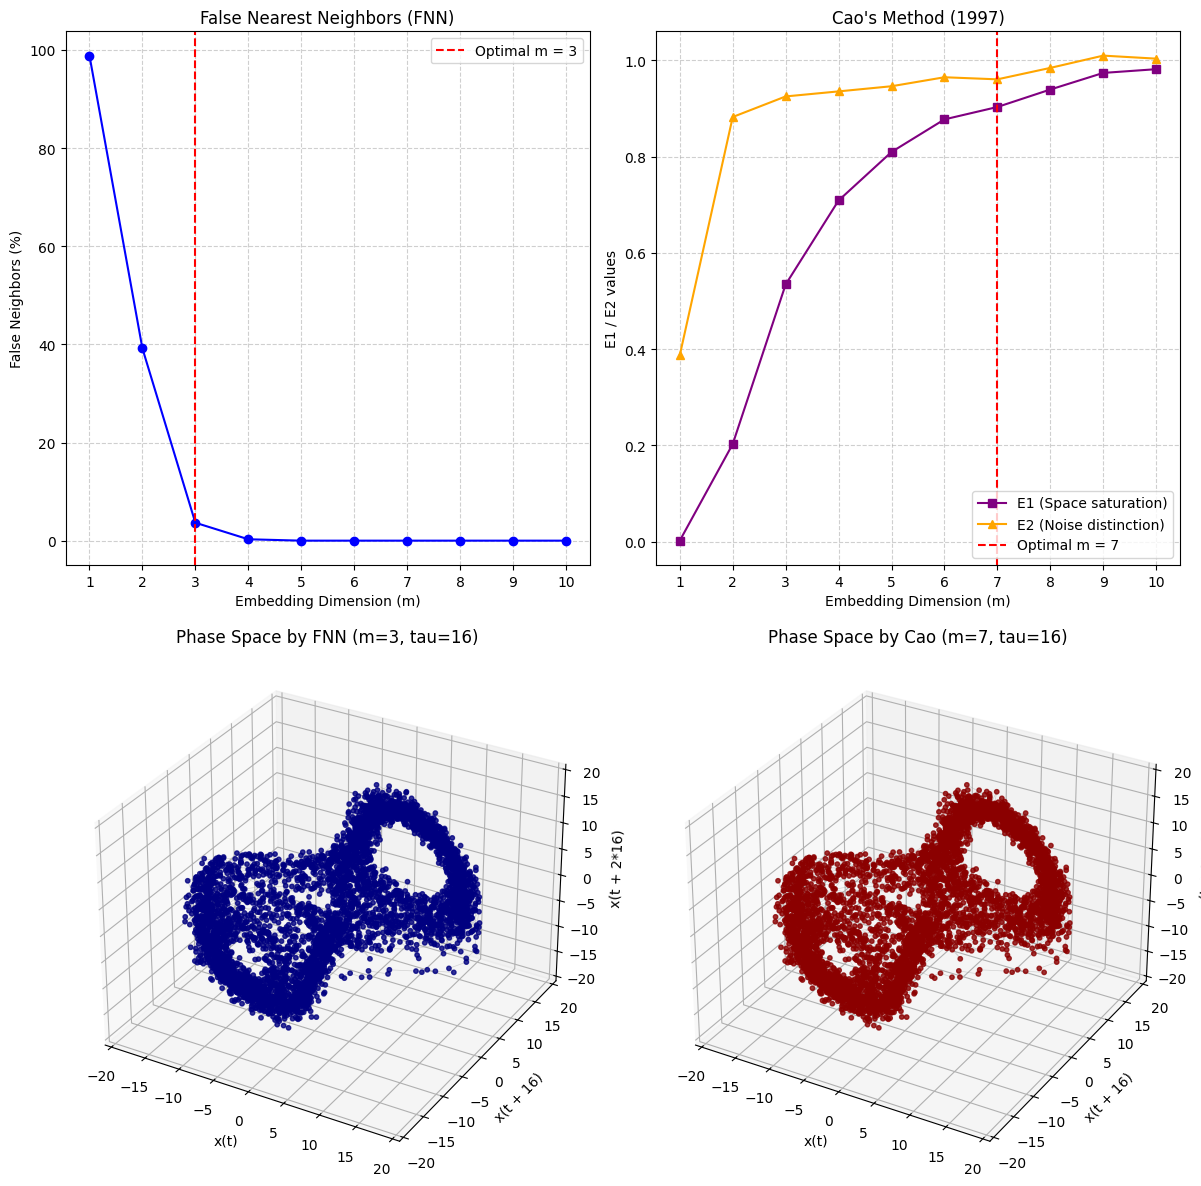

In [34]:
x_noise = add_white_noise(x_clean, snr_db=20.0)
def find_optimal_m_fnn(dims, fnn_percentages, threshold=10.0):
    """
    Tìm số chiều m tối ưu từ thuật toán FNN.
    Lựa chọn m đầu tiên mà tại đó tỷ lệ láng giềng giả nhỏ hơn ngưỡng threshold (%).
    """
    valid_indices = np.where(np.array(fnn_percentages) < threshold)[0]
    if len(valid_indices) > 0:
        return dims[valid_indices[0]]
    # Nếu không hội tụ, trả về m tại điểm có tỷ lệ nhỏ nhất
    return dims[np.argmin(fnn_percentages)]

def find_optimal_m_cao(dims, E1, threshold_diff=0.03):
    """
    Tìm số chiều m tối ưu từ thuật toán Cao (1997).
    Lựa chọn m khi đại lượng E1 bắt đầu bão hòa (sự thay đổi giữa các bậc rất nhỏ).
    """
    E1_array = np.array(E1)
    for i in range(1, len(E1_array)):
        if abs(E1_array[i] - E1_array[i-1]) < threshold_diff:
            # Trả về số chiều tương ứng với điểm bão hòa
            return dims[i]
    return dims[-1]

# 1. Thiết lập tham số đầu vào
# Kế thừa độ trễ tối ưu (tau = 9) đã tìm được từ bước Mutual Information
opt_tau = 16
max_m_check = 10

# 2. Chạy thuật toán FNN và Cao's Method
dims_fnn, fnn_percentages = false_nearest_neighbors(x_noise, opt_tau, max_m=max_m_check)
dims_cao, E1_vals, E2_vals = cao_method(x_noise, opt_tau, max_m=max_m_check)

# 3. Tự động xác định số chiều nhúng tối ưu
m_opt_fnn = find_optimal_m_fnn(dims_fnn, fnn_percentages)
m_opt_cao = find_optimal_m_cao(dims_cao, E1_vals)

print(f"So chieu toi uu theo FNN: {m_opt_fnn}")
print(f"So chieu toi uu theo Cao's Method: {m_opt_cao}")

# 4. Tái tạo Không gian pha bằng số chiều đã tìm được
ps_fnn = delay_embedding(x_noise, opt_tau, m_opt_fnn)
ps_cao = delay_embedding(x_noise, opt_tau, m_opt_cao)

# ==========================================
# 5. TRỰC QUAN HÓA SO SÁNH (GRID 2x2)
# ==========================================
fig = plt.figure(figsize=(12, 12))

# Đồ thị 1: False Nearest Neighbors (FNN)
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(dims_fnn, fnn_percentages, marker='o', color='blue', linewidth=1.5)
ax1.axvline(x=m_opt_fnn, color='red', linestyle='--', label=f'Optimal m = {m_opt_fnn}')
ax1.set_title("False Nearest Neighbors (FNN)")
ax1.set_xlabel("Embedding Dimension (m)")
ax1.set_ylabel("False Neighbors (%)")
ax1.set_xticks(dims_fnn)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 2: Cao's Method (E1 và E2)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(dims_cao[:len(E1_vals)], E1_vals, marker='s', color='purple', label='E1 (Space saturation)')
# Kiểm tra độ dài E2 để tránh lỗi index (do thuật toán Cao tính E2 phụ thuộc chiều d)
if len(E2_vals) > 0:
    ax2.plot(dims_cao[:len(E2_vals)], E2_vals, marker='^', color='orange', label='E2 (Noise distinction)')
ax2.axvline(x=m_opt_cao, color='red', linestyle='--', label=f'Optimal m = {m_opt_cao}')
ax2.set_title("Cao's Method (1997)")
ax2.set_xlabel("Embedding Dimension (m)")
ax2.set_ylabel("E1 / E2 values")
ax2.set_xticks(dims_cao)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 3: Không gian pha theo m của FNN
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# Dù m_opt có lớn hơn 3, ta vẫn chỉ vẽ 3 chiều đầu tiên để trực quan hóa
ax3.plot(ps_fnn[:, 0], ps_fnn[:, 1], ps_fnn[:, 2], color='gray', alpha=0.3, linewidth=0.5)
ax3.scatter(ps_fnn[:, 0], ps_fnn[:, 1], ps_fnn[:, 2], color='navy', s=10, alpha=0.8)
ax3.set_title(f"Phase Space by FNN (m={m_opt_fnn}, tau={opt_tau})")
ax3.set_xlabel("x(t)")
ax3.set_ylabel(f"x(t + {opt_tau})")
ax3.set_zlabel(f"x(t + 2*{opt_tau})")

# Đồ thị 4: Không gian pha theo m của Cao's Method
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot(ps_cao[:, 0], ps_cao[:, 1], ps_cao[:, 2], color='gray', alpha=0.3, linewidth=0.5)
ax4.scatter(ps_cao[:, 0], ps_cao[:, 1], ps_cao[:, 2], color='darkred', s=10, alpha=0.8)
ax4.set_title(f"Phase Space by Cao (m={m_opt_cao}, tau={opt_tau})")
ax4.set_xlabel("x(t)")
ax4.set_ylabel(f"x(t + {opt_tau})")
ax4.set_zlabel(f"x(t + 2*{opt_tau})")

plt.tight_layout()
plt.show()